In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/processed/loan_data_engineered.csv")
print(df.shape)

(1345350, 50)


In [3]:
import lightgbm as lgb
print(lgb.__version__)

4.7.0


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
from sklearn.metrics import roc_auc_score

In [7]:
drop_cols = ['loan_status', 'default', 'earliest_cr_line']

In [8]:
X = df.drop(columns=drop_cols)
y = df['default']

In [9]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    X[col] = X[col].astype('category')

C:\Users\ARYAN DASH\AppData\Local\Temp\ipykernel_15992\3967489894.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.tolist()


In [10]:
print(X.shape)
print('earliest_cr_line' in X.columns)
print(categorical_cols)

(1345350, 47)
False
['term', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
model = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=100,
    deterministic=True,
    force_row_wise=True
)

In [31]:
model.fit(X_train, y_train, categorical_feature=categorical_cols)

[LightGBM] [Info] Number of positive: 214879, number of negative: 861401
[LightGBM] [Info] Total Bins 5648
[LightGBM] [Info] Number of data points in the train set: 1076280, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199650 -> initscore=-1.388485
[LightGBM] [Info] Start training from score -1.388485


,random_state,42
,deterministic,True
,force_row_wise,True
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [32]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test AUC: {auc:.4f}")

Test AUC: 0.7219


## Baseline Model
# LightGBM with default hyperparameters, no imbalance handling
# Test AUC: 0.7219

In [33]:
from sklearn.metrics import confusion_matrix , classification_report

In [34]:
y_pred = model.predict(X_test)

In [37]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n")

cr = classification_report(y_test, y_pred)
print(cr)

[[212176   3174]
 [ 49259   4461]]


              precision    recall  f1-score   support

           0       0.81      0.99      0.89    215350
           1       0.58      0.08      0.15     53720

    accuracy                           0.81    269070
   macro avg       0.70      0.53      0.52    269070
weighted avg       0.77      0.81      0.74    269070



In [38]:
import matplotlib.pyplot as plt

In [39]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending = False)

print(importance_df.head(15))

                  feature  importance
8              addr_state         546
41  installment_to_income         185
28   mo_sin_old_rev_tl_op         152
2             installment         150
9                     dti         147
10         fico_range_low         123
7                 purpose         114
32     num_tl_op_past_12m         114
3              emp_length         101
44    revol_bal_to_income         100
37         total_bc_limit          96
1                    term          87
19              total_acc          86
31        num_actv_rev_tl          80
43   credit_history_years          69


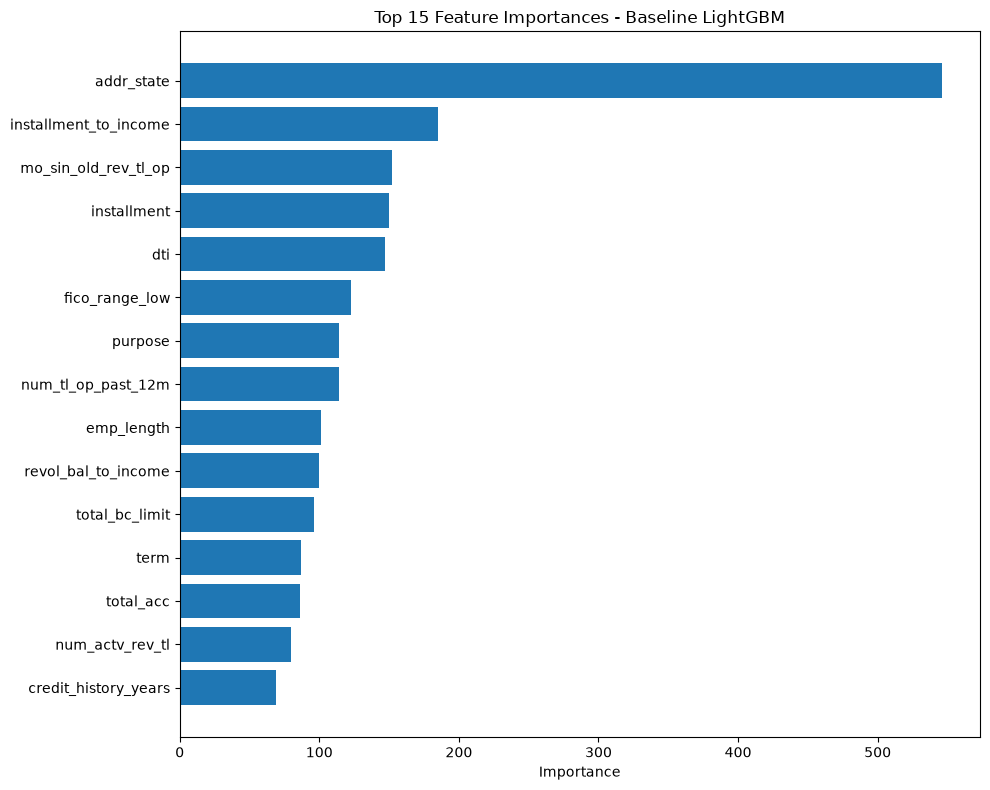

In [40]:
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'][:15][::-1], importance_df['importance'][:15][::-1])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Baseline LightGBM')
plt.tight_layout()
plt.savefig('../reports/figures/baseline_feature_importance.png')
plt.show()

In [41]:
state_default_rates = df.groupby('addr_state')['default'].agg(['mean', 'count']).sort_values('mean', ascending=False)

print(state_default_rates.head(10))
print(state_default_rates.tail(10))

                mean   count
addr_state                  
MS          0.260777    6588
NE          0.251813    3586
AR          0.240868   10047
AL          0.236321   16613
OK          0.234753   12281
LA          0.231821   15499
NY          0.220484  109849
NV          0.219223   20267
FL          0.214787   95611
IN          0.214082   21716
                mean  count
addr_state                 
SC          0.162821  15993
WA          0.157594  29189
CO          0.155269  29671
WV          0.155187   4878
NH          0.145759   6449
OR          0.144059  16410
IA          0.142857      7
VT          0.139517   2652
ME          0.138424   2030
DC          0.132086   3475


In [13]:
import joblib 

In [43]:
joblib.dump(model, '../models/baseline_lightgbm.pkl')
print("Model saved")

Model saved


In [14]:
model = joblib.load('../models/baseline_lightgbm.pkl')

In [15]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test AUC: {auc:.4f}")

Test AUC: 0.7219


## Task 3 Summary: Baseline LightGBM Model

- Default hyperparameters, n_estimators=100, deterministic=True for reproducibility
- Excludes int_rate, grade, sub_grade (avoids leakage from Lending Club's own underwriting model)
- Test AUC: 0.7166
- Recall on default class at 0.5 threshold: 0.08 — expected given class imbalance, not yet addressed
- Top features: addr_state, installment_to_income, mo_sin_old_rev_tl_op, installment, dti, fico_range_low
- addr_state shows real regional signal (verified via groupby default rate check, ~13pt spread across states with large sample sizes) but its raw importance score is likely inflated by high cardinality — kept in model, but not over-interpreted as literally more predictive than FICO/DTI
- Next: Task 4 — imbalance handling (scale_pos_weight/is_unbalance vs. SMOTE)